# Assignment 3: Attention and Transformers in PyTorch

**Student ID:** 2024320307  
**Name:** 누린 아마니 빈티 잠베리

**Grading (100 points)**

| Item | Topic | Points |
|---|---|---:|
| 1.1 | Multi-Head Scaled Dot-Product Attention | 15 |
| 1.2 | Positional Encoding | 8 |
| 1.3 | Attention Design Choices | 6 |
| 1.4 | Transformer Decoder Layer | 10 |
| 1.5 | Transformer Captioning Module | 13 |
| 1.6 | Greedy Sampling | 8 |
|  | **Part 1 subtotal** | **60** |
| 2.1 | Patch Embedding | 10 |
| 2.2 | Transformer Encoder Layer | 8 |
| 2.3 | Vision Transformer Forward Pass | 8 |
| 2.4 | Train the Vision Transformer | 6 |
| 2.5 | ViTs on Small Datasets | 4 |
| 2.6 | Self-Attention Cost | 4 |
|  | **Part 2 subtotal** | **40** |
|  | **Total** | **100** |


## Assignment Overview

In this assignment, you will implement the attention mechanism and the main
building blocks of the Transformer in PyTorch. You will use them in two
models: a Transformer decoder for image captioning on MS-COCO and a Vision
Transformer (ViT) for image classification on CIFAR-10. PyTorch autograd
computes all backward passes.

- **Part 1 — Attention and Transformer Captioning:** Implement multi-headed
  scaled dot-product attention and sinusoidal positional encoding, build a
  Transformer decoder layer and a captioning model, train it on a small COCO
  subset, and generate captions with greedy decoding.
- **Part 2 — Vision Transformer:** Implement patch embedding, a Transformer
  encoder layer, and the ViT forward pass, then train the ViT on CIFAR-10.

### Goals

- Understand queries, keys, values, and attention weights.
- Implement multi-headed attention with masking using `torch.Tensor` operations.
- Understand why Transformers need positional encodings.
- Build decoder and encoder layers from attention, feedforward, residual, and
  normalization sublayers.
- Use causal masking for autoregressive caption generation.
- Apply the same Transformer components to images with patch embeddings.

### References and Conventions

Statements labeled **Lecture Connection** quote the CSAI202 lecture notes
(Lec01–Lec04); each citation names the lecture and the page number of its PDF.
Attention- and Transformer-specific explanations are labeled **Concept
Connection** because the lectures introduce attention only as the motivation
for the Transformer (Lec04, p. 33).

Unless stated otherwise, `N` is batch size, `T` is sequence length, `E` is the
embedding dimension, `H` is the number of attention heads, `W` is the
word-vector dimension, `D` is the input-feature dimension, `V` is vocabulary
size, and `P` is the patch size. Inside `MultiHeadAttention`, `S` is the query
length and `T` is the key/value length; they are equal for self-attention. In
a decoder, `M` is the length of the memory used by cross-attention. In image
shapes `(N, C, H, W)`, `C`, `H`, and `W` are the channels, height, and width.

Run the notebook from top to bottom. Do not use `nn.MultiheadAttention`,
`F.scaled_dot_product_attention`, `nn.TransformerEncoderLayer`,
`nn.TransformerDecoderLayer`, `nn.TransformerEncoder`, `nn.TransformerDecoder`,
or `nn.Transformer` in your implementations.


## Colab Setup: Download the COCO Captioning Dataset

The archive contains captions and precomputed VGG-16 image features. Its size is
approximately 1 GB. The download is skipped if the extracted directory already
exists in the current runtime.

Progress bars show the download and extraction progress.


In [1]:
import shutil
import urllib.request
import zipfile
from pathlib import Path

from tqdm.auto import tqdm

DATASET_DIR = Path('datasets')
COCO_DIR = DATASET_DIR / 'coco_captioning'
URL = 'https://cs231n.stanford.edu/coco_captioning.zip'

if COCO_DIR.is_dir():
    print('COCO captioning data already exist; skipping download.')
else:
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    archive = DATASET_DIR / 'coco_captioning.zip'
    partial_dir = DATASET_DIR / 'coco_captioning.partial'

    print('Downloading COCO captioning data...')
    with urllib.request.urlopen(URL) as response, open(archive, 'wb') as f:
        total = int(response.headers.get('Content-Length', 0)) or None
        with tqdm(total=total, unit='B', unit_scale=True, unit_divisor=1024,
                  desc='Download') as progress:
            while chunk := response.read(1 << 20):
                f.write(chunk)
                progress.update(len(chunk))

    # Extract into a temporary directory first, so an interrupted run never
    # leaves a half-extracted COCO_DIR that would be skipped next time.
    shutil.rmtree(partial_dir, ignore_errors=True)
    with zipfile.ZipFile(archive) as zf:
        members = zf.infolist()
        with tqdm(total=sum(m.file_size for m in members), unit='B', unit_scale=True,
                  unit_divisor=1024, desc='Extract') as progress:
            for member in members:
                zf.extract(member, partial_dir)
                progress.update(member.file_size)
    (partial_dir / 'coco_captioning').rename(COCO_DIR)
    shutil.rmtree(partial_dir)
    archive.unlink()
    print('COCO captioning data are ready.')


Download:   0%|          | 0.00/987M [00:00<?, ?B/s]

Extract:   0%|          | 0.00/2.17G [00:00<?, ?B/s]

COCO captioning data are ready.


In [2]:
%pip install -q h5py imageio


#### Setup


In [3]:
import copy
import json
import math
import os
import random
import tempfile
import urllib.error
import urllib.request
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from imageio.v2 import imread
from torch.utils.data import DataLoader, Dataset

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0)
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

SEED = 231
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


def max_relative_error(x, y, eps=1e-8):
    """Return the maximum elementwise relative error between two tensors."""
    x = x.detach().cpu()
    y = y.detach().cpu()
    return ((x - y).abs() / torch.clamp(x.abs() + y.abs(), min=eps)).max().item()


Using device: cpu


#### Provided: COCO Data Utilities and Temporal Loss

The following code loads the precomputed image features and captions. You
do not need to modify these helpers.


In [4]:
COCO_DIR = Path('datasets/coco_captioning')


def load_coco_data(base_dir=COCO_DIR, pca_features=True):
    base_dir = Path(base_dir)
    data = {}

    with h5py.File(base_dir / 'coco2014_captions.h5', 'r') as f:
        for key, value in f.items():
            data[key] = np.asarray(value)

    train_name = 'train2014_vgg16_fc7_pca.h5' if pca_features else 'train2014_vgg16_fc7.h5'
    val_name = 'val2014_vgg16_fc7_pca.h5' if pca_features else 'val2014_vgg16_fc7.h5'
    with h5py.File(base_dir / train_name, 'r') as f:
        data['train_features'] = np.asarray(f['features'], dtype=np.float32)
    with h5py.File(base_dir / val_name, 'r') as f:
        data['val_features'] = np.asarray(f['features'], dtype=np.float32)

    with open(base_dir / 'coco2014_vocab.json') as f:
        data.update(json.load(f))
    with open(base_dir / 'train2014_urls.txt') as f:
        data['train_urls'] = np.asarray([line.strip() for line in f])
    with open(base_dir / 'val2014_urls.txt') as f:
        data['val_urls'] = np.asarray([line.strip() for line in f])
    return data


def decode_captions(captions, idx_to_word):
    captions = np.asarray(captions)
    single = captions.ndim == 1
    if single:
        captions = captions[None]
    decoded = []
    for caption in captions:
        words = []
        for token in caption:
            word = idx_to_word[int(token)]
            if word != '<NULL>':
                words.append(word)
            if word == '<END>':
                break
        decoded.append(' '.join(words))
    return decoded[0] if single else decoded


def image_from_url(url):
    try:
        response = urllib.request.urlopen(url, timeout=10)
        fd, filename = tempfile.mkstemp()
        os.close(fd)
        with open(filename, 'wb') as f:
            f.write(response.read())
        image = imread(filename)
        os.remove(filename)
        return image
    except (urllib.error.URLError, urllib.error.HTTPError, TimeoutError) as exc:
        print('Could not download image:', exc)
        return None


class CocoCaptionDataset(Dataset):
    """A PyTorch view of the precomputed COCO captioning arrays."""

    def __init__(self, data, split='train', max_examples=None, seed=SEED):
        captions = data[f'{split}_captions']
        image_idxs = data[f'{split}_image_idxs']
        if max_examples is not None and max_examples < len(captions):
            rng = np.random.default_rng(seed)
            keep = rng.choice(len(captions), size=max_examples, replace=False)
            captions = captions[keep]
            image_idxs = image_idxs[keep]
        self.captions = captions.astype(np.int64)
        self.image_idxs = image_idxs.astype(np.int64)
        self.features = data[f'{split}_features']

    def __len__(self):
        return len(self.captions)

    def __getitem__(self, index):
        feature = self.features[self.image_idxs[index]]
        return torch.from_numpy(feature).float(), torch.from_numpy(self.captions[index]).long()


def temporal_cross_entropy(logits, targets, null_index):
    """Cross-entropy over all non-NULL tokens."""
    return F.cross_entropy(
        logits.reshape(-1, logits.shape[-1]),
        targets.reshape(-1),
        ignore_index=null_index,
    )


In [5]:
# Load the dataset once for Part 1.
data = load_coco_data(pca_features=True)
for key, value in data.items():
    if isinstance(value, np.ndarray):
        print(f'{key}: {value.shape}')

input_dim = data['train_features'].shape[1]
vocab_size = len(data['word_to_idx'])
null_index = data['word_to_idx']['<NULL>']
start_index = data['word_to_idx']['<START>']
print('input_dim:', input_dim, 'vocab_size:', vocab_size)


train_captions: (400135, 17)
train_image_idxs: (400135,)
val_captions: (195954, 17)
val_image_idxs: (195954,)
train_features: (82783, 512)
val_features: (40504, 512)
train_urls: (82783,)
val_urls: (40504,)
input_dim: 512 vocab_size: 1004


## Part 1: Attention and Transformer Captioning (60 points)

RNNs process a sequence one step at a time, which limits parallelism and makes
long-range dependencies hard to learn. The Transformer
([Vaswani et al., 2017](https://arxiv.org/abs/1706.03762)) replaces recurrence
with **attention**: every position directly gathers information from every
other position it is allowed to see.

**Lecture Connection**

> Recurrent dependencies limit parallel computation  
> Long sequences increase sequential processing time  
> *(Lec04 Recurrent Neural Networks, p. 32)*

> Sequential state updates restrict parallel computation  
> Attention removes the need to pass all interactions through recurrent steps → Motivation of Transformer architecture  
> *(Lec04 Recurrent Neural Networks, p. 33)*

Given a query $q\in\mathbb{R}^d$, keys $\{k_1,\dots,k_n\}$, and values
$\{v_1,\dots,v_n\}$, attention returns a weighted average of the values:

$$
c = \sum_{i=1}^{n} \alpha_i v_i,\qquad
\alpha_i = \frac{\exp(k_i^\top q)}{\sum_{j=1}^{n} \exp(k_j^\top q)}.
$$

The $\alpha_i$ are the **attention weights**. In **self-attention**, queries,
keys, and values are all computed from the same input sequence
$X\in\mathbb{R}^{\ell\times d}$ with learned matrices $Q, K, V$:
$q_i = Qx_i$, $k_i = Kx_i$, $v_i = Vx_i$.


### Section 1: Attention Building Blocks


#### Question 1.1: Multi-Head Scaled Dot-Product Attention [code] (15 points)

Implement multi-headed scaled dot-product attention without using
`nn.MultiheadAttention` or `F.scaled_dot_product_attention`.

**Lecture Connection**

> The logits represent relative preference among classes  
> Softmax can convert them into class probabilities  
> *(Lec02 Feedforward Neural Networks, p. 32)*

> Correct tensor shapes are essential for neural-network computation.  
> Many implementation errors are actually shape mismatches  
> *(Lec01 Foundations of Deep Learning, p. 19)*

**Concept Connection**

Each of the $h$ heads has its own projections $Q_i, K_i, V_i \in
\mathbb{R}^{d\times d/h}$, so the total cost matches one full-width head:

$$
Y_i = \text{dropout}\bigg(\text{softmax}\bigg(\frac{(XQ_i)(XK_i)^\top}{\sqrt{d/h}}\bigg)\bigg)(XV_i),
\qquad
Y = [Y_1;\dots;Y_h]A .
$$

For cross-attention, the query comes from one sequence and the keys and values
from another. A mask removes forbidden query–key pairs by setting their scores
to $-\infty$ before the softmax, which makes their attention weights exactly 0.

**Implementation Guide and Point Breakdown**

The four linear layers (`query`, `key`, `value`, `proj`) and the dropout are
already created. Do not reorder them: the provided check depends on their
random initialization.

- **Projections and heads (5 points):** Apply `self.query`, `self.key`, and
  `self.value`, then reshape the queries to `(N, H, S, E/H)` and the keys
  and values to `(N, H, T, E/H)`.
- **Scaled and masked scores (5 points):** Compute `(N, H, S, T)` scores with
  `torch.matmul`, divide by $\sqrt{E/H}$, and set positions where
  `attn_mask == 0` to `-inf`.
- **Weighted values and output (5 points):** Apply softmax over the key axis,
  then `self.attn_drop`, multiply by the values, merge the heads back to
  `(N, S, E)`, and apply `self.proj`.

| Tensor | Shape |
|---|---|
| `query` | `(N, S, E)` |
| `key`, `value` | `(N, T, E)` |
| `attn_mask` | `(S, T)` |
| per-head queries | `(N, H, S, E/H)` |
| attention scores | `(N, H, S, T)` |
| `output` | `(N, S, E)` |

**Expected Check:** Self-attention, masked self-attention, and cross-attention
outputs each have relative error below `7e-3`.


In [6]:
class MultiHeadAttention(nn.Module):
    """
    Multi-headed scaled dot-product attention, as introduced in
    "Attention Is All You Need" (https://arxiv.org/abs/1706.03762).

    Usage:
      attn = MultiHeadAttention(embed_dim, num_heads=2)
      self_attn_output = attn(query=x, key=x, value=x)
      cross_attn_output = attn(query=x, key=other_x, value=other_x)
    """

    def __init__(self, embed_dim, num_heads, dropout=0.1):
        super().__init__()
        assert embed_dim % num_heads == 0

        # The layers are created for you. Do not change their order: it fixes
        # the random initialization used by the provided check.
        self.key = nn.Linear(embed_dim, embed_dim)
        self.query = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)
        self.proj = nn.Linear(embed_dim, embed_dim)

        self.attn_drop = nn.Dropout(dropout)

        self.n_head = num_heads
        self.embed_dim = embed_dim
        self.head_dim = embed_dim // num_heads

    def forward(self, query, key, value, attn_mask=None):
        """
        Inputs:
        - query: Tensor of shape (N, S, E)
        - key: Tensor of shape (N, T, E)
        - value: Tensor of shape (N, T, E)
        - attn_mask: Tensor of shape (S, T). attn_mask[i, j] == 0 means that
          query position i must not attend to key position j.

        Returns:
        - output: Tensor of shape (N, S, E)
        """
        N, S, E = query.shape
        N, T, E = value.shape
        ########################################################################
        # TODO 1.1 (15 points): Implement multi-headed scaled dot-product      #
        # attention.                                                           #
        # 1. Project query, key, and value, then split E into H heads of size  #
        # E/H.                                                                 #
        # 2. Compute (N, H, S, T) scores with torch.matmul and divide by       #
        # sqrt(E/H).                                                           #
        # 3. Where attn_mask == 0, set the score to -inf (masked_fill) before  #
        # softmax.                                                             #
        # 4. Apply softmax over the key axis, then self.attn_drop.             #
        # 5. Weight the values, merge the heads back to (N, S, E), apply       #
        # self.proj.                                                           #
        ########################################################################

        # Project query, key, and value, then split into heads
        q = self.query(query).reshape(N, S, self.n_head, self.head_dim).transpose(1, 2)
        k = self.key(key).reshape(N, T, self.n_head, self.head_dim).transpose(1, 2)
        v = self.value(value).reshape(N, T, self.n_head, self.head_dim).transpose(1, 2)

        # Compute scaled dot-product attention scores
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        # Apply attention mask, if provided
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask.unsqueeze(0).unsqueeze(0) == 0, float('-inf'))

        # Normalize scores and apply dropout
        attn_weights = F.softmax(scores, dim=-1)
        attn_weights = self.attn_drop(attn_weights)

        # Compute weighted values and merge attention heads
        context = torch.matmul(attn_weights, v)
        context = context.transpose(1, 2).contiguous().reshape(N, S, E)

        # Final output projection
        output = self.proj(context)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return output


In [7]:
# Provided check: compare your attention layer with precomputed outputs.
torch.manual_seed(SEED)

# The dimensions are all distinct for easier debugging:
# N=1, H=2, S=T=3, E/H=4, and E=8.
batch_size = 1
sequence_length = 3
embed_dim = 8
attn = MultiHeadAttention(embed_dim, num_heads=2)
attn.eval()

# Self-attention.
x = torch.randn(batch_size, sequence_length, embed_dim)
self_attn_output = attn(query=x, key=x, value=x)

# Masked self-attention.
mask = torch.randn(sequence_length, sequence_length) < 0.5
masked_self_attn_output = attn(query=x, key=x, value=x, attn_mask=mask)

# Attention using two inputs.
other_x = torch.randn(batch_size, sequence_length, embed_dim)
attn_output = attn(query=x, key=other_x, value=other_x)

expected_self_attn_output = np.asarray([[
    [-0.1030,  0.2090,  0.7481, -0.4116, -0.2772,  0.2357, -0.2740, -0.2798],
    [-0.1794,  0.1637,  0.6930, -0.3435, -0.2300,  0.2457, -0.2504, -0.2323],
    [-0.1861,  0.1567,  0.6677, -0.3078, -0.2731,  0.2302, -0.2714, -0.2082]]])

expected_masked_self_attn_output = np.asarray([[
    [-0.1209,  0.1806,  0.8056, -0.4654, -0.2262,  0.2552, -0.2544, -0.2812],
    [-0.2374,  0.1183,  0.7423, -0.3777, -0.1460,  0.2716, -0.2213, -0.2077],
    [-0.0851,  0.2423,  0.7941, -0.3778, -0.4924,  0.1512, -0.4241, -0.1740]]])

expected_attn_output = np.asarray([[
    [-0.1965,  0.0702,  0.5227, -0.1388, -0.3530,  0.2163, -0.2643, -0.1902],
    [-0.3592, -0.0899,  0.5836,  0.0029, -0.3643,  0.2667, -0.1973, -0.1698],
    [-0.3795,  0.0433,  0.5634, -0.0749, -0.4379,  0.2714, -0.2207, -0.1980]]])

errors = {
    'self_attn_output': max_relative_error(torch.from_numpy(expected_self_attn_output), self_attn_output),
    'masked_self_attn_output': max_relative_error(torch.from_numpy(expected_masked_self_attn_output), masked_self_attn_output),
    'attn_output': max_relative_error(torch.from_numpy(expected_attn_output), attn_output),
}
for name, error in errors.items():
    print(f'{name} error:', error)
    assert error < 7e-3


self_attn_output error: 0.0001792071437561575
masked_self_attn_output error: 9.739464922734568e-05
attn_output error: 0.006226898176165351


#### Question 1.2: Positional Encoding [code] (8 points)

**Lecture Connection**

> Reordering elements can change the meaning of a sequence  
> Sequence position cannot generally be treated independently  
> *(Lec04 Recurrent Neural Networks, p. 5)*

**Concept Connection**

Attention treats its input as a set: permuting the tokens permutes the outputs
in the same way, so the model cannot tell word order on its own. The
Transformer adds a fixed positional encoding $P\in\mathbb{R}^{\ell\times d}$
to the token embeddings and feeds $X + P$ to the network, where

$$
P_{ij} =
\begin{cases}
\sin\left(i \cdot 10000^{-\frac{j}{d}}\right) & \text{if } j \text{ is even} \\
\cos\left(i \cdot 10000^{-\frac{(j-1)}{d}}\right) & \text{otherwise.}
\end{cases}
$$

**Implementation Guide and Point Breakdown**

- **Encoding table (5 points):** Fill the buffer `pe` of shape
  `(1, max_len, E)` in `__init__`. Even columns use sine and odd columns use
  cosine; columns `2k` and `2k+1` share the exponent `2k/E`. This can be done
  without a Python loop by slicing `pe[0, :, 0::2]` and `pe[0, :, 1::2]`.
- **Forward (3 points):** Add the first `T` rows of `pe` to `x` (broadcasting
  over the batch), then apply `self.dropout`.

| Tensor | Shape |
|---|---|
| `pe` buffer | `(1, max_len, E)` |
| `x` | `(N, T, E)` |
| `output` | `(N, T, E)` |

**Expected Check:** Relative error below `1e-3`.


In [8]:
class PositionalEncoding(nn.Module):
    """
    Adds fixed sinusoidal position information to a sequence of embeddings.
    The layer has no learnable parameters.
    """

    def __init__(self, embed_dim, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        assert embed_dim % 2 == 0
        # The leading dimension of size 1 broadcasts across the batch.
        pe = torch.zeros(1, max_len, embed_dim)
        ########################################################################
        # TODO 1.2 (5/8 points): Fill pe so that even columns hold sines and   #
        # odd columns hold cosines, with exponents 0, 0, 2, 2, 4, 4, ... as in #
        # the equation above.                                                  #
        ########################################################################

        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, embed_dim, 2, dtype=torch.float32)
            * (-math.log(10000.0) / embed_dim)
        )

        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################

        # Register pe as a buffer so it moves with the module (e.g., .to(device)).
        self.register_buffer('pe', pe)

    def forward(self, x):
        """
        Inputs:
        - x: Tensor of shape (N, T, E)

        Returns:
        - output: x plus positional encodings, of shape (N, T, E)
        """
        N, T, E = x.shape
        ########################################################################
        # TODO 1.2 (3/8 points): Add the first T positional encodings to x,    #
        # then apply dropout.                                                  #
        ########################################################################
        output = self.dropout(x + self.pe[:, :T, :])
        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return output


In [9]:
# Provided check: compare your positional encoding with precomputed outputs.
torch.manual_seed(SEED)

batch_size = 1
sequence_length = 2
embed_dim = 6
x = torch.randn(batch_size, sequence_length, embed_dim)

pos_encoder = PositionalEncoding(embed_dim)
pos_encoder.eval()
output = pos_encoder(x)

expected_pe_output = np.asarray([[[-1.1106,  1.0014,  1.5280, -0.0778, -0.6964,  1.1455],
                                  [ 0.8125, -0.4303,  0.4981,  0.7320,  1.1380,  1.5331]]])
pe_error = max_relative_error(torch.from_numpy(expected_pe_output), output)
print('pe_output error:', pe_error)
assert pe_error < 1e-3


pe_output error: 0.00021699471301977143


#### Question 1.3: Attention Design Choices [written] (6 points)

---

Several design decisions were made in the scaled dot-product attention above.
Explain why each of the following choices is beneficial:

1. Using multiple attention heads instead of one.
2. Dividing by $\sqrt{d/h}$ before applying the softmax, where $d$ is the
   feature dimension and $h$ is the number of heads.
3. Adding a linear transformation to the output of the attention operation.

One or two sentences per choice are enough (2 points each). For each choice,
state what would happen without it, why that is a problem, and how the choice
fixes it.

$\color{blue}{\textit Your Answer:}$

<!-- ANSWER_START: 1.3 -->

1. **Multiple attention heads:** Multiple heads allow the model to learn different types of relationships between tokens simultaneously. Without them, a single head may capture fewer types of relationships, limiting the model's ability to represent complex information.

2. **Scaling by \(\sqrt{d/h}\):** Dividing the attention scores by the square root of the head dimension prevents the scores from becoming too large, which could make softmax produce extremely peaked probabilities and weak gradients. Without scaling, training may become less stable and slower.

3. **Output linear transformation:** The output projection combines information from different attention heads and transforms it into the desired embedding dimension. Without it, the heads' outputs would simply be concatenated without a learned transformation, limiting how their information can be integrated.

<!-- ANSWER_END: 1.3 -->

---


### Section 2: Transformer Captioning Model and Training


#### Question 1.4: Transformer Decoder Layer [code] (10 points)

**Lecture Connection**

> A residual block computes y = F(x) + x  
> The identity branch preserves the original representation  
> *(Lec03 Convolutional Neural Networks, p. 29)*

> Gradients can propagate through the identity branch  
> Optimization remains effective at greater depth  
> *(Lec03 Convolutional Neural Networks, p. 30)*

> The encoder state provides context for the decoder  
> *(Lec04 Recurrent Neural Networks, p. 18)*

**Concept Connection**

A Transformer decoder layer has three sublayers:

1. **Masked self-attention** over the caption tokens, so each position can use
   the earlier words.
2. **Cross-attention**, whose queries come from the caption and whose keys and
   values come from the *memory* (here, the projected image feature).
3. A position-wise **feedforward network** applied to every token
   independently.

Each sublayer is wrapped as `LayerNorm(x + Dropout(Sublayer(x)))`. The residual
connection gives gradients a direct path through deep stacks, and LayerNorm
keeps the activations well scaled.

**Implementation Guide and Point Breakdown**

The feedforward network is provided below, and the self-attention block is
already written in `forward`. Use it as the pattern for the remaining blocks.

- **Cross-attention block (5 points):** Use `tgt` as the query and `memory` as
  the key and value; then apply `self.dropout_cross`, add the residual, and
  apply `self.norm_cross`. No mask is needed.
- **Feedforward block (5 points):** Apply `self.ffn`, `self.dropout_ffn`, the
  residual add, and `self.norm_ffn`.

| Tensor | Shape |
|---|---|
| `tgt` | `(N, T, E)` |
| `memory` | `(N, M, E)` |
| `tgt_mask` | `(T, T)` |
| output | `(N, T, E)` |

**Expected Check:** Relative error below `1e-6`.


In [10]:
# Provided: position-wise feedforward network used by decoder and encoder layers.
class FeedForwardNetwork(nn.Module):
    def __init__(self, embed_dim, ffn_dim, dropout=0.1):
        """
        Two-layer feedforward network with a GELU activation and dropout.

        Inputs:
         - embed_dim: Dimension of input and output embeddings
         - ffn_dim: Hidden dimension of the feedforward network
         - dropout: Dropout probability
        """
        super().__init__()
        self.fc1 = nn.Linear(embed_dim, ffn_dim)
        self.gelu = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.fc2 = nn.Linear(ffn_dim, embed_dim)

    def forward(self, x):
        out = self.fc1(x)
        out = self.gelu(out)
        out = self.dropout(out)
        out = self.fc2(out)
        return out


In [11]:
class TransformerDecoderLayer(nn.Module):
    """A single Transformer decoder layer."""

    def __init__(self, input_dim, num_heads, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(input_dim, num_heads, dropout)
        self.cross_attn = MultiHeadAttention(input_dim, num_heads, dropout)
        self.ffn = FeedForwardNetwork(input_dim, dim_feedforward, dropout)

        self.norm_self = nn.LayerNorm(input_dim)
        self.norm_cross = nn.LayerNorm(input_dim)
        self.norm_ffn = nn.LayerNorm(input_dim)

        self.dropout_self = nn.Dropout(dropout)
        self.dropout_cross = nn.Dropout(dropout)
        self.dropout_ffn = nn.Dropout(dropout)

    def forward(self, tgt, memory, tgt_mask=None):
        """
        Inputs:
        - tgt: Target sequence, of shape (N, T, E)
        - memory: Sequence to attend to (e.g., image features), of shape (N, M, E)
        - tgt_mask: Mask for the target self-attention, of shape (T, T)

        Returns:
        - tgt: Output features, of shape (N, T, E)
        """
        # Self-attention block (provided).
        shortcut = tgt
        tgt = self.self_attn(query=tgt, key=tgt, value=tgt, attn_mask=tgt_mask)
        tgt = self.dropout_self(tgt)
        tgt = tgt + shortcut
        tgt = self.norm_self(tgt)

        ########################################################################
        # TODO 1.4 (10 points): Implement the cross-attention block (query:    #
        # tgt, key/value: memory) and the feedforward block. Follow the self-  #
        # attention block above: sublayer -> dropout -> residual add ->        #
        # LayerNorm.                                                           #
        ########################################################################

        # Cross-attention block
        shortcut = tgt
        tgt = self.cross_attn(query=tgt, key=memory, value=memory)
        tgt = self.dropout_cross(tgt)
        tgt = tgt + shortcut
        tgt = self.norm_cross(tgt)

        # Feedforward block
        shortcut = tgt
        tgt = self.ffn(tgt)
        tgt = self.dropout_ffn(tgt)
        tgt = tgt + shortcut
        tgt = self.norm_ffn(tgt)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return tgt


In [12]:
# Provided check: compare your decoder layer with precomputed outputs.
torch.manual_seed(SEED)

N, T, TM, D = 1, 4, 5, 12

decoder_layer = TransformerDecoderLayer(D, 2, 4*D)
decoder_layer.eval()
tgt = torch.randn(N, T, D)
memory = torch.randn(N, TM, D)
tgt_mask = torch.randn(T, T) < 0.5

output = decoder_layer(tgt, memory, tgt_mask)

expected_output = np.asarray([
    [[ 0.27005595, -0.21056601,  0.63376445, -0.35391954,  0.60071295,
      -1.7566615,  -0.1314159,  -1.7659538,  -0.5575517,   0.680143,
       1.8622686,   0.7291234],
     [-0.6080135,   0.4421802,  -0.07590749, -0.12093157,  0.94722354,
      -1.0223433,   0.47332686, -1.3958666,   2.1890075,  -1.0380646,
       0.9437816,  -0.7343922],
     [-0.89690155,  0.60447216,  0.10688882,  0.03492759,  1.8388084,
      -0.9772293,   0.7621334,  -0.668234,    1.3260399,  -1.8417019,
       0.21718435, -0.506388],
     [-0.70961505, -0.02918372, -0.39894593, -0.8069395,   0.04967685,
       0.29345992,  0.7871747,  -1.3172938,   1.4744806,   1.2633642,
       1.1611108,  -1.767289]]
])
decoder_error = max_relative_error(torch.from_numpy(expected_output), output)
print('decoder error:', decoder_error)
assert decoder_error < 1e-6


decoder error: 7.225322480055846e-07


#### Question 1.5: Transformer Captioning Module [code] (13 points)

The captioning model embeds the caption tokens, adds positional encodings, and
runs a stack of decoder layers whose cross-attention looks at the projected
image feature. A final linear layer maps each position to vocabulary logits.

**Lecture Connection**

> One to sequence generates multiple outputs from one context  
> *(Lec04 Recurrent Neural Networks, p. 15)*

> No Softmax layer is required before CrossEntropyLoss  
> The loss function internally performs the appropriate normalization  
> *(Lec02 Feedforward Neural Networks, p. 55)*

> A device mismatch prevents the computation from proceeding correctly  
> *(Lec01 Foundations of Deep Learning, p. 54)*

**Concept Connection**

During training the whole caption is given at once (teacher forcing), and all
positions are processed in parallel. To keep the model from looking ahead, the
self-attention uses a **causal mask**: position $t$ may attend only to
positions $\le t$. A lower-triangular matrix of ones is exactly this mask.

**Implementation Guide and Point Breakdown**

All modules are created in `__init__`; `TransformerDecoder` (provided below)
stacks copies of your decoder layer. Do not reorder the modules in `__init__`.

- **Inputs to the decoder (5 points):** Embed `captions` with
  `self.embedding`, add positional encodings, and project `features` with
  `self.visual_projection` to a memory of shape `(N, 1, W)`.
- **Causal mask (4 points):** Build a `(T, T)` lower-triangular mask with
  `torch.tril`, created on `captions.device`.
- **Decoder and scores (4 points):** Run `self.transformer` with the mask and
  map its output to vocabulary scores with `self.output`.

| Stage | Shape |
|---|---|
| image features | `(N, D)` |
| image memory | `(N, 1, W)` |
| caption token indices | `(N, T)` |
| embeddings + positions | `(N, T, W)` |
| causal mask | `(T, T)` |
| vocabulary scores | `(N, T, V)` |

**Expected Check:** Relative error below `1e-5`.


In [13]:
# Provided: a stack of identical decoder layers.
def clones(module, N):
    """Produce N identical layers."""
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])


class TransformerDecoder(nn.Module):
    def __init__(self, decoder_layer, num_layers):
        super().__init__()
        self.layers = clones(decoder_layer, num_layers)
        self.num_layers = num_layers

    def forward(self, tgt, memory, tgt_mask=None):
        output = tgt
        for mod in self.layers:
            output = mod(output, memory, tgt_mask=tgt_mask)
        return output


In [14]:
class CaptioningTransformer(nn.Module):
    """
    Produces captions from image features with a Transformer decoder.
    """

    def __init__(self, word_to_idx, input_dim, wordvec_dim, num_heads=4,
                 num_layers=2, max_length=50):
        """
        Inputs:
        - word_to_idx: Vocabulary dictionary with V entries mapping words to [0, V).
        - input_dim: Dimension D of input image feature vectors.
        - wordvec_dim: Dimension W of word vectors.
        - num_heads: Number of attention heads.
        - num_layers: Number of decoder layers.
        - max_length: Maximum possible sequence length.
        """
        super().__init__()

        vocab_size = len(word_to_idx)
        self.vocab_size = vocab_size
        self._null = word_to_idx["<NULL>"]
        self._start = word_to_idx.get("<START>", None)
        self._end = word_to_idx.get("<END>", None)

        self.visual_projection = nn.Linear(input_dim, wordvec_dim)
        self.embedding = nn.Embedding(vocab_size, wordvec_dim, padding_idx=self._null)
        self.positional_encoding = PositionalEncoding(wordvec_dim, max_len=max_length)

        decoder_layer = TransformerDecoderLayer(input_dim=wordvec_dim, num_heads=num_heads)
        self.transformer = TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.apply(self._init_weights)

        self.output = nn.Linear(wordvec_dim, vocab_size)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(self, features, captions):
        """
        Inputs:
        - features: Image features, of shape (N, D)
        - captions: Caption tokens, of shape (N, T)

        Returns:
        - scores: Vocabulary scores for every timestep, of shape (N, T, V)
        """
        N, T = captions.shape
        ########################################################################
        # TODO 1.5 (13 points): Implement the captioning forward pass.         #
        # 1. Embed the caption tokens and add positional encodings.            #
        # 2. Project the image features to (N, 1, W) to use as the decoder     #
        # memory.                                                              #
        # 3. Build a (T, T) causal mask with torch.tril on captions.device.    #
        # 4. Run the decoder and project its output to vocabulary scores.      #
        ########################################################################

        # 1. Embed caption tokens and add positional encodings
        tgt = self.embedding(captions)
        tgt = self.positional_encoding(tgt)

        # 2. Project image features to decoder memory: (N, 1, W)
        memory = self.visual_projection(features).unsqueeze(1)

        # 3. Build a causal mask: position t can attend only to positions <= t
        tgt_mask = torch.tril(
            torch.ones(T, T, device=captions.device)
        )

        # 4. Run the Transformer decoder and project to vocabulary scores
        tgt = self.transformer(tgt, memory, tgt_mask=tgt_mask)
        scores = self.output(tgt)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return scores


In [15]:
# Provided check: compare your captioning model with precomputed scores.
torch.manual_seed(SEED)

N, D, W = 4, 20, 30
toy_word_to_idx = {'<NULL>': 0, 'cat': 2, 'dog': 3}
V = len(toy_word_to_idx)
T = 3

toy_transformer = CaptioningTransformer(
    toy_word_to_idx,
    input_dim=D,
    wordvec_dim=W,
    num_heads=2,
    num_layers=2,
    max_length=30,
)
toy_transformer.eval()

features = torch.randn(N, D)
captions = torch.randint(0, V, (N, T))

scores = toy_transformer(features, captions)

expected_scores = np.asarray([
    [[ 0.62165695, -0.6203744,  -1.116114  ],
     [ 0.6641097,  -0.60309553, -1.3479083 ],
     [ 0.62117404, -0.79205745, -1.1095243 ]],
    [[ 0.62160987, -0.6214724,  -1.1171186 ],
     [ 0.6093992,  -0.61166143, -1.3365762 ],
     [ 0.62108713, -0.79322916, -1.1104958 ]],
    [[ 0.6406587,  -0.57419956, -1.1300566 ],
     [ 0.6075228,  -0.60872054, -1.3372457 ],
     [ 0.6471472,  -0.8270494,  -1.1064028 ]],
    [[ 0.64029807, -0.5755552,  -1.1284486 ],
     [ 0.60708034, -0.6099963,  -1.3356377 ],
     [ 0.59367496, -0.8346836,  -1.0914496 ]]
])
scores_error = max_relative_error(torch.from_numpy(expected_scores), scores)
print('scores error:', scores_error)
assert scores_error < 1e-5


scores error: 2.597067229886812e-07


#### Provided: Overfit the Transformer Captioner on Small Data

**Lecture Connection**

> PyTorch accumulates gradients unless they are cleared  
> Therefore a standard iteration includes: Clear previous gradients → Compute predictions → Compute loss → Compute new gradients → Update parameters  
> *(Lec01 Foundations of Deep Learning, p. 52)*

The training loop below is provided. Train the captioning model on a fixed
subset of 50 COCO captions as an end-to-end correctness check.

**Expected Check:** The loss should decrease strongly and finish below `0.1`.


In [16]:
def train_captioner(model, loader, num_epochs, learning_rate, null_index, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_history = []
    model.to(device)

    for epoch in range(1, num_epochs + 1):
        model.train()
        epoch_loss = 0.0
        example_count = 0
        for features, captions in loader:
            features = features.to(device)
            captions = captions.to(device)
            captions_in = captions[:, :-1]
            captions_out = captions[:, 1:]

            optimizer.zero_grad()
            logits = model(features, captions_in)
            loss = temporal_cross_entropy(logits, captions_out, null_index)
            loss.backward()
            optimizer.step()

            batch_size = features.shape[0]
            epoch_loss += loss.item() * batch_size
            example_count += batch_size

        mean_loss = epoch_loss / example_count
        loss_history.append(mean_loss)
        if epoch == 1 or epoch % 10 == 0 or epoch == num_epochs:
            print(f'Epoch {epoch:3d}/{num_epochs}: loss {mean_loss:.4f}')

    return loss_history


Epoch   1/100: loss 6.4085
Epoch  10/100: loss 2.8221
Epoch  20/100: loss 1.7715
Epoch  30/100: loss 1.0518
Epoch  40/100: loss 0.4818
Epoch  50/100: loss 0.2222
Epoch  60/100: loss 0.1090
Epoch  70/100: loss 0.0857
Epoch  80/100: loss 0.0509
Epoch  90/100: loss 0.0311
Epoch 100/100: loss 0.0375


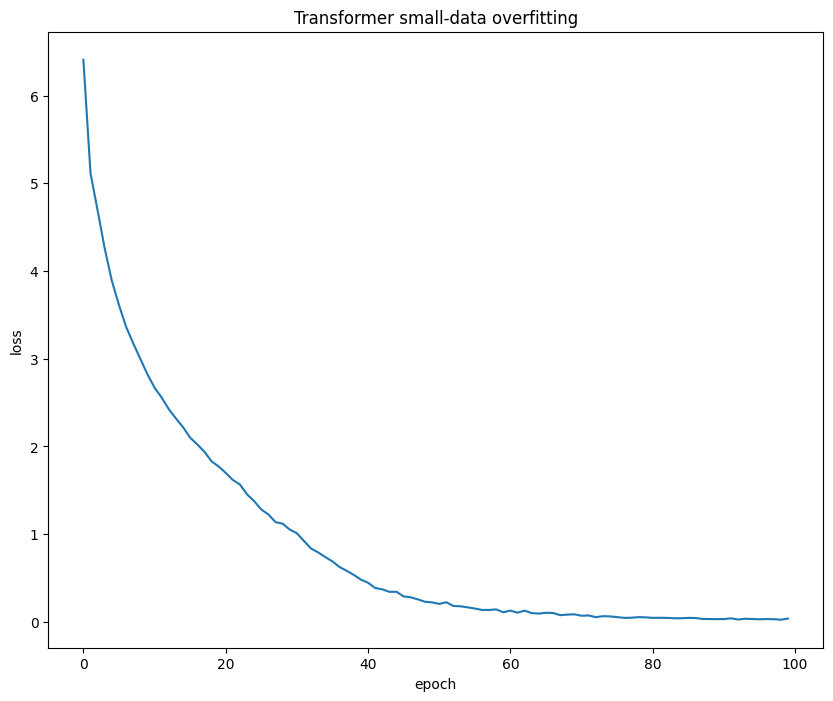

Final Transformer loss: 0.037519932724535465


In [17]:
# Overfit a small COCO subset as an end-to-end correctness check.
small_train = CocoCaptionDataset(data, split='train', max_examples=50, seed=SEED)
caption_loader = DataLoader(small_train, batch_size=25, shuffle=True)

torch.manual_seed(SEED)
transformer = CaptioningTransformer(
    data['word_to_idx'], input_dim=input_dim, wordvec_dim=256,
    num_heads=2, num_layers=2, max_length=30,
)
transformer_loss_history = train_captioner(
    transformer, caption_loader, num_epochs=100, learning_rate=1e-3,
    null_index=null_index, device=device,
)

plt.plot(transformer_loss_history)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('Transformer small-data overfitting')
plt.show()
print('Final Transformer loss:', transformer_loss_history[-1])


#### Question 1.6: Greedy Sampling [code] (8 points)

Implement `transformer_sample` in the code cell below. It is attached to
`CaptioningTransformer` as the `sample` method, so `self` refers to the
captioning model and the trained `transformer` can use it without retraining.

**Lecture Connection**

> The decoder generates target elements sequentially  
> *(Lec04 Recurrent Neural Networks, p. 18)*

> Overfitting: Training performance is very good  
> Validation performance is substantially worse  
> *(Lec02 Feedforward Neural Networks, p. 43)*

**Concept Connection**

At test time there is no ground-truth caption, so the model generates one token
at a time and feeds its own predictions back in. Unlike an RNN, the Transformer
keeps no hidden state between steps: at every step it reruns `forward` on the
entire partial caption, and the causal mask guarantees that the last position
sees only earlier tokens. Greedy decoding picks the largest logit at the last
position.

**Implementation Guide**

1. Fill `captions` of shape `(N, max_length)` with `<NULL>` and start the
   partial caption as a `(N, 1)` tensor of `<START>` tokens. Create both on
   `features.device` with dtype `torch.long`.
2. At each step, call `self.forward(features, partial_caption)` and keep only
   the logits of the last timestep.
3. Select `argmax(dim=1)`, store it in `captions[:, t]`, and append it to the
   partial caption with `torch.cat`.

| Tensor | Shape |
|---|---|
| `features` | `(N, D)` |
| partial caption at step `t` | `(N, t + 1)` |
| last-step logits | `(N, V)` |
| output `captions` | `(N, max_length)` |

**Expected Check:** The provided check confirms that `sample` returns a
`torch.long` tensor of shape `(N, max_length)` with valid token indices. After
successful small-data overfitting, generated training captions should contain
recognizable words or phrases from their references.


In [18]:
@torch.no_grad()
def transformer_sample(self, features, max_length=30):
    ############################################################################
    # TODO 1.6 (8 points): Implement greedy caption generation. Start from     #
    # <START>; at every step run self.forward on the whole partial caption,    #
    # take the argmax of the last timestep, store it in captions, and append   #
    # it to the partial caption.                                               #
    ############################################################################
    captions = None

    N = features.shape[0]

    # Initialize captions with <START> tokens
    captions = torch.full(
        (N, max_length),
        self._null,
        dtype=torch.long,
        device=features.device
    )
    partial_caption = torch.full(
        (N, 1),
        self._start,
        dtype=torch.long,
        device=features.device
    )

    # Generate one token at a time
    for t in range(max_length):
        scores = self.forward(features, partial_caption)

        # Select the highest-scoring token at the last timestep
        next_token = scores[:, -1, :].argmax(dim=1)

        # Store the generated token
        captions[:, t] = next_token

        # Stop generating for sequences that have produced <END>
        partial_caption = torch.cat(
            [partial_caption, next_token.unsqueeze(1)],
           dim=1
        )

        if self._end is not None and (next_token == self._end).all():
            break

    ############################################################################
    #                         END OF YOUR CODE                                 #
    ############################################################################
    return captions


# Attach the sampler to CaptioningTransformer. The already trained transformer
# uses it immediately, so the training cell does not need to be re-run.
CaptioningTransformer.sample = transformer_sample


In [19]:
# Provided check: greedy sampling returns integer token indices of shape (N, max_length).
transformer.eval()
for split, features in [
    ('train', torch.from_numpy(data['train_features'][small_train.image_idxs[:3]])),
    ('val', torch.from_numpy(data['val_features'][:3])),
]:
    sampled = transformer.sample(features.float().to(device), max_length=7)
    assert torch.is_tensor(sampled), f'{split}: sample must return a torch.Tensor'
    assert sampled.shape == (3, 7), f'{split}: expected shape (3, 7), got {tuple(sampled.shape)}'
    assert sampled.dtype == torch.long, f'{split}: expected torch.long, got {sampled.dtype}'
    assert ((sampled >= 0) & (sampled < vocab_size)).all(), f'{split}: token index out of range'
print('Transformer sampling check passed')


Transformer sampling check passed


GT:   <START> a <UNK> with vegetables as a side dish <END>
Pred: a <UNK> with vegetables as a side dish <END>
Could not download image: HTTP Error 502: Bad Gateway
GT:   <START> several zebras drinking out of a water hole <END>
Pred: several zebras drinking out of a water hole <END>
Could not download image: HTTP Error 502: Bad Gateway
GT:   <START> a group of zebras shown in a outdoor enclosure <END>
Pred: a <UNK> sitting in a grass yard out side <END>


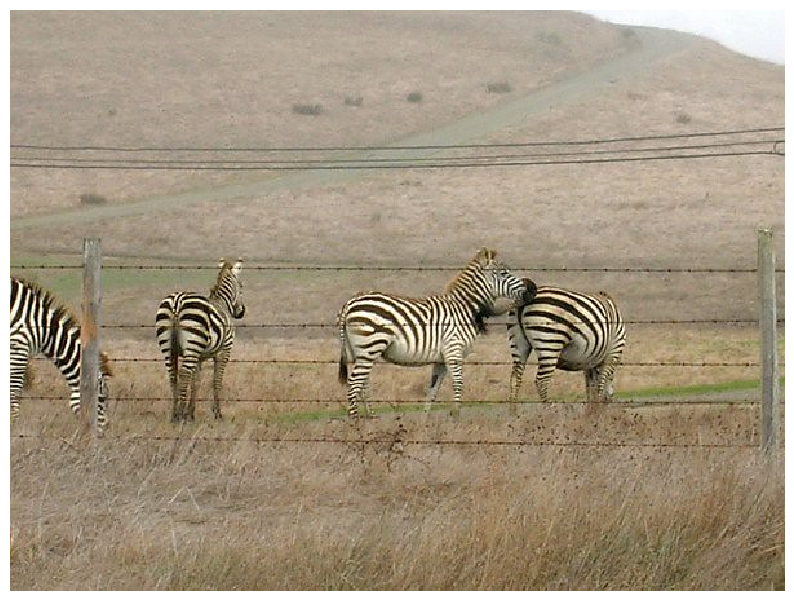

GT:   <START> two transit trains are pulled up at a station with passengers walking <UNK> <END>
Pred: a city colorful planes gold with people remote <END>


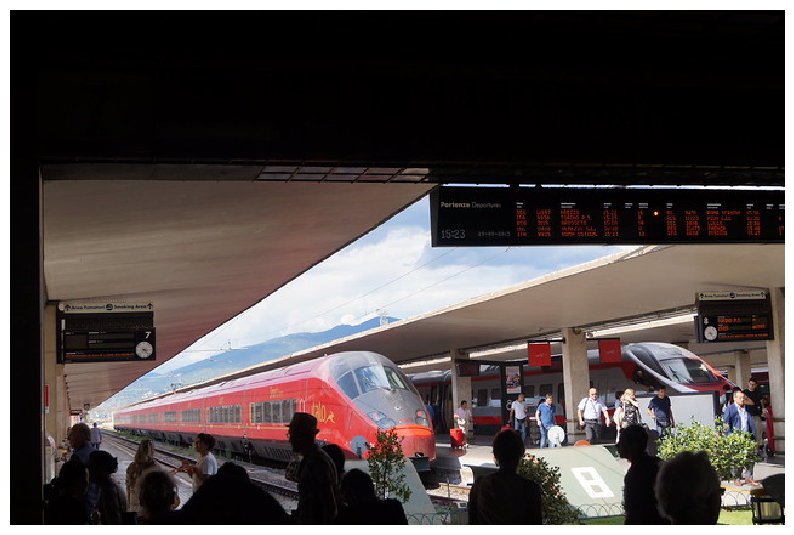

In [20]:
def show_samples(model, data, split='train', count=2, dataset=None):
    model.eval()
    rng = np.random.default_rng(SEED)
    if dataset is not None:
        # Sample from the given subset, e.g. the examples the model was trained on.
        picks = rng.choice(len(dataset), size=count, replace=False)
        captions = dataset.captions[picks]
        image_indices = dataset.image_idxs[picks]
    else:
        caption_count = len(data[f'{split}_captions'])
        caption_indices = rng.choice(caption_count, size=count, replace=False)
        captions = data[f'{split}_captions'][caption_indices]
        image_indices = data[f'{split}_image_idxs'][caption_indices]
    features = torch.from_numpy(data[f'{split}_features'][image_indices]).float().to(device)
    predicted = model.sample(features).cpu().numpy()

    ground_truth = decode_captions(captions, data['idx_to_word'])
    generated = decode_captions(predicted, data['idx_to_word'])
    for gt, pred, image_index in zip(ground_truth, generated, image_indices):
        print('GT:  ', gt)
        print('Pred:', pred)
        image = image_from_url(data[f'{split}_urls'][image_index])
        if image is not None:
            plt.imshow(image)
            plt.axis('off')
            plt.show()


show_samples(transformer, data, split='train', dataset=small_train)
show_samples(transformer, data, split='val')


## Part 2: Vision Transformer (40 points)

[Dosovitskiy et al. (2020)](https://arxiv.org/abs/2010.11929) showed that a
Transformer applied to a sequence of image patches, the **Vision Transformer
(ViT)**, performs very well and scales better than convolutional networks when
trained on large datasets. In this part you will build a ViT from your
attention layer and train it on CIFAR-10.

A ViT cuts the image into non-overlapping patches, embeds each patch as a
token, adds positional encodings, and processes the token sequence with
Transformer **encoder** layers. Every token can attend to every other token,
so no causal mask is needed. The token vectors are then average-pooled and
classified.


### Section 3: Vision Transformer Components


#### Question 2.1: Patch Embedding [code] (10 points)

**Lecture Connection**

> Input shape uses N × Cin × H × W  
> *(Lec03 Convolutional Neural Networks, p. 13)*

> Parameters do not directly depend on image width or height  
> Shared weights improve statistical efficiency  
> *(Lec03 Convolutional Neural Networks, p. 17)*

**Concept Connection**

A patch embedding turns an image into a sequence. A `(C, H, W)` image split
into `P x P` patches yields $(H/P)(W/P)$ tokens, and each flattened patch of
$C \cdot P \cdot P$ values is mapped to an `E`-dimensional vector by one
shared linear layer.

**Implementation Guide and Point Breakdown**

- **Patch extraction (6 points):** Without a Python loop, reshape `x` from
  `(N, C, H, W)` to `(N, C, H/P, P, W/P, P)`, permute it so that the two patch
  grid axes come before the `(C, P, P)` patch contents, and flatten it to
  `(N, num_patches, patch_dim)`. Patches must be ordered row by row, and each
  patch must be flattened in `(C, P, P)` order.
- **Projection (4 points):** Apply `self.proj` to every patch vector.

| Tensor | Shape |
|---|---|
| `x` | `(N, C, H, W)` |
| reshaped image | `(N, C, H/P, P, W/P, P)` |
| flattened patches | `(N, num_patches, C*P*P)` |
| `out` | `(N, num_patches, E)` |

**Expected Check:** Relative error below `1e-4`.


In [21]:
class PatchEmbedding(nn.Module):
    """
    Splits an image into patches and projects each patch to an embedding
    vector. This is the input layer of a Vision Transformer.

    Inputs:
    - img_size: Height/width of the (square) input image.
    - patch_size: Height/width of each (square) patch.
    - in_channels: Number of input image channels.
    - embed_dim: Dimension of the patch embeddings.
    """

    def __init__(self, img_size, patch_size, in_channels=3, embed_dim=128):
        super().__init__()

        self.img_size = img_size
        self.patch_size = patch_size
        self.in_channels = in_channels
        self.embed_dim = embed_dim

        assert img_size % patch_size == 0, "Image dimensions must be divisible by the patch size."

        self.num_patches = (img_size // patch_size) ** 2
        self.patch_dim = patch_size * patch_size * in_channels

        # Linear projection of flattened patches to the embedding dimension.
        self.proj = nn.Linear(self.patch_dim, embed_dim)

    def forward(self, x):
        """
        Inputs:
        - x: Image tensor of shape (N, C, H, W)

        Returns:
        - out: Patch embeddings of shape (N, num_patches, embed_dim)
        """
        N, C, H, W = x.shape
        assert H == self.img_size and W == self.img_size, \
            f"Expected image size ({self.img_size}, {self.img_size}), but got ({H}, {W})"
        ########################################################################
        # TODO 2.1 (10 points): Split x into non-overlapping (C, P, P)         #
        # patches, flatten them to (N, num_patches, patch_dim) without a       #
        # Python loop (torch.reshape and torch.permute help), and embed them   #
        # with self.proj.                                                      #
        ########################################################################

        # Split the image into non-overlapping patches
        P = self.patch_size
        x = x.reshape(N, C, H // P, P, W // P, P)

        # Move the patch-grid dimensions before the patch contents
        x = x.permute(0, 2, 4, 1, 3, 5)

        # Flatten each patch into a vector
        x = x.reshape(N, self.num_patches, self.patch_dim)

        # Project each patch into the embedding dimension
        out = self.proj(x)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return out


In [22]:
# Provided check: compare your patch embedding with precomputed outputs.
torch.manual_seed(SEED)

N = 2
HW = 16
PS = 8
D = 8

patch_embedding = PatchEmbedding(
    img_size=HW,
    patch_size=PS,
    embed_dim=D
)

x = torch.randn(N, 3, HW, HW)
output = patch_embedding(x)

expected_output = np.asarray([
        [[-0.6312704 ,  0.02531429,  0.6112642 , -0.49089882,
          0.01412961, -0.6959372 , -0.32862484, -0.45402682],
        [ 0.18816411, -0.08142513, -0.9829535 , -0.23975623,
         -0.23109074,  0.97950286, -0.40997326,  0.7457837 ],
        [ 0.01810865,  0.15780598, -0.91804236,  0.36185235,
          0.8379501 ,  1.0191797 , -0.29667392,  0.20322265],
        [-0.18697818, -0.45137224, -0.40339014, -1.4381214 ,
         -0.43450755,  0.7651071 , -0.83683825, -0.16360264]],

       [[-0.39786366,  0.16201034, -0.19008337, -1.0602452 ,
         -0.28693503,  0.09791763,  0.26614824,  0.41781986],
        [ 0.35146567, -0.4469593 , -0.1841726 ,  0.45757473,
         -0.61304873, -0.29104248, -0.16124889, -0.14987172],
        [-0.2996967 ,  0.27353522, -0.09929767,  0.01973832,
         -1.2312065 , -0.6374332 , -0.22963578,  0.55696607],
        [-0.93818814,  0.02465284, -0.21117875,  1.1860403 ,
         -0.06137538, -0.21062079, -0.094347  ,  0.50032747]]])

patch_error = max_relative_error(torch.from_numpy(expected_output), output)
print('patch embedding error:', patch_error)
assert patch_error < 1e-4


patch embedding error: 4.900488074289221e-06


#### Question 2.2: Transformer Encoder Layer [code] (8 points)

**Lecture Connection**

> During training: Some hidden activations are randomly set to zero  
> During inference: The full network is used  
> *(Lec02 Feedforward Neural Networks, p. 47)*

**Concept Connection**

An encoder layer is a decoder layer without cross-attention: a self-attention
block followed by a feedforward block, each wrapped as
`LayerNorm(x + Dropout(Sublayer(x)))`. Because every patch may attend to every
other patch, a mask is not needed for ViT, but the layer still accepts one for
consistency with the decoder.

**Implementation Guide and Point Breakdown**

- **Self-attention block (4 points):** Use `src` as query, key, and value and
  pass `src_mask` as `attn_mask`; then apply `self.dropout_self`, the residual
  add, and `self.norm_self`.
- **Feedforward block (4 points):** Apply `self.ffn`, `self.dropout_ffn`, the
  residual add, and `self.norm_ffn`.

`TransformerEncoder`, which stacks encoder layers, is provided below.

| Tensor | Shape |
|---|---|
| `src` | `(N, T, E)` |
| `src_mask` | `(T, T)` |
| output | `(N, T, E)` |

**Expected Check:** Relative error below `1e-6`.


In [23]:
class TransformerEncoderLayer(nn.Module):
    """A single Transformer encoder layer."""

    def __init__(self, input_dim, num_heads, dim_feedforward=2048, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(input_dim, num_heads, dropout)
        self.ffn = FeedForwardNetwork(input_dim, dim_feedforward, dropout)

        self.norm_self = nn.LayerNorm(input_dim)
        self.norm_ffn = nn.LayerNorm(input_dim)

        self.dropout_self = nn.Dropout(dropout)
        self.dropout_ffn = nn.Dropout(dropout)

    def forward(self, src, src_mask=None):
        """
        Inputs:
        - src: Input sequence, of shape (N, T, E)
        - src_mask: Mask for the self-attention, of shape (T, T)

        Returns:
        - src: Output features, of shape (N, T, E)
        """
        ########################################################################
        # TODO 2.2 (8 points): Apply a self-attention block followed by a      #
        # feedforward block. Each block follows the decoder pattern: sublayer  #
        # -> dropout -> residual add -> LayerNorm.                             #
        ########################################################################

        # Self-attention block
        shortcut = src
        src = self.self_attn(
            query=src,
            key=src,
            value=src,
            attn_mask=src_mask
        )
        src = self.dropout_self(src)
        src = src + shortcut
        src = self.norm_self(src)

        # Feedforward block
        shortcut = src
        src = self.ffn(src)
        src = self.dropout_ffn(src)
        src = src + shortcut
        src = self.norm_ffn(src)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return src


In [24]:
# Provided: a stack of identical encoder layers.
class TransformerEncoder(nn.Module):
    def __init__(self, encoder_layer, num_layers):
        super().__init__()
        self.layers = clones(encoder_layer, num_layers)
        self.num_layers = num_layers

    def forward(self, src, src_mask=None):
        output = src
        for mod in self.layers:
            output = mod(output, src_mask=src_mask)
        return output


In [25]:
# Provided check: compare your encoder layer with precomputed outputs.
torch.manual_seed(SEED)

N, T, TM, D = 1, 4, 5, 12

encoder_layer = TransformerEncoderLayer(D, 2, 4*D)
encoder_layer.eval()
x = torch.randn(N, T, D)
x_mask = torch.randn(T, T) < 0.5

output = encoder_layer(x, x_mask)

expected_output = np.asarray([
    [[-0.48887438, -0.16470742,  0.7249629,  -1.0907345,   1.5764195,
       0.17484017,  0.8643941,  -0.5209561,  -1.6651545,  -1.1943513,
       1.4809005,   0.30326116],
     [-0.14663944,  1.052812,   -0.96227,    -0.20350897, -2.1478589,
       1.2637341,   0.04015125, -0.945255,    1.408903,   -0.43051198,
       0.37110543,  0.69933903],
     [ 0.08718029,  0.91050833, -1.208469,    1.1440394,  -1.9794976,
      -0.38342738, -0.47407156, -0.17345548,  0.11738186,  1.9534125,
       0.3525986,  -0.3461999],
     [-0.81389004,  0.76213264, -0.7094313,  -1.5332246,   1.3837544,
       0.4091982,   0.6569406,   0.7305365,  -1.197077,   -1.3698943,
       0.58292854,  1.0980265]]
])
encoder_error = max_relative_error(torch.from_numpy(expected_output), output)
print('encoder error:', encoder_error)
assert encoder_error < 1e-6


encoder error: 3.436711054227157e-07


#### Question 2.3: Vision Transformer Forward Pass [code] (8 points)

**Lecture Connection**

> Global average pooling → N × 64  
> Linear classifier → N × number of classes  
> *(Lec03 Convolutional Neural Networks, p. 41)*

**Concept Connection**

The ViT reuses the same 1D sinusoidal positional encoding as the captioning
model to give each patch token its position; 2D sinusoidal and learned
positional encodings are also valid choices. After the encoder, the patch
vectors are average-pooled into one vector per image and classified by a
linear head.

**Implementation Guide and Point Breakdown**

All modules are created in `__init__`.

- **Tokens with positions (3 points):** Apply `self.patch_embed`, then
  `self.positional_encoding`.
- **Encoder (2 points):** Run `self.transformer` on the token sequence.
- **Pooling and classifier (3 points):** Average over the token axis with
  `torch.mean` and apply `self.head`.

| Stage | Shape |
|---|---|
| images | `(N, C, H, W)` |
| patch tokens | `(N, num_patches, E)` |
| encoder output | `(N, num_patches, E)` |
| pooled features | `(N, E)` |
| `logits` | `(N, num_classes)` |

**Expected Check:** Relative error below `1e-5`.


In [26]:
class VisionTransformer(nn.Module):
    """Vision Transformer (ViT) for image classification."""

    def __init__(self, img_size=32, patch_size=8, in_channels=3,
                 embed_dim=128, num_layers=6, num_heads=4,
                 dim_feedforward=256, num_classes=10, dropout=0.1):
        """
        Inputs:
         - img_size: Size of the (square) input image.
         - patch_size: Size of each (square) patch.
         - in_channels: Number of image channels.
         - embed_dim: Embedding dimension of each patch token.
         - num_layers: Number of Transformer encoder layers.
         - num_heads: Number of attention heads.
         - dim_feedforward: Hidden size of the feedforward network.
         - num_classes: Number of classes.
         - dropout: Dropout probability.
        """
        super().__init__()
        self.num_classes = num_classes
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        self.positional_encoding = PositionalEncoding(embed_dim, dropout=dropout)

        encoder_layer = TransformerEncoderLayer(embed_dim, num_heads, dim_feedforward, dropout)
        self.transformer = TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Final classification layer that maps the pooled features to class scores.
        self.head = nn.Linear(embed_dim, num_classes)

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(self, x):
        """
        Inputs:
         - x: Image tensor of shape (N, C, H, W)

        Returns:
         - logits: Classification logits of shape (N, num_classes)
        """
        ########################################################################
        # TODO 2.3 (8 points): Implement the Vision Transformer forward pass.  #
        # 1. Convert the image into a sequence of patch embeddings.            #
        # 2. Add positional encodings.                                         #
        # 3. Run the Transformer encoder.                                      #
        # 4. Average-pool the patch vectors (torch.mean) and apply self.head.  #
        ########################################################################

        # 1. Convert images into patch embeddings
        tokens = self.patch_embed(x)

        # 2. Add positional encodings
        tokens = self.positional_encoding(tokens)

        # 3. Run the Transformer encoder
        tokens = self.transformer(tokens)

        # 4. Average-pool over patches and classify
        pooled = torch.mean(tokens, dim=1)
        logits = self.head(pooled)

        ########################################################################
        #                         END OF YOUR CODE                             #
        ########################################################################
        return logits


In [27]:
# Provided check: compare your ViT with precomputed scores.
torch.manual_seed(SEED)

imgs = torch.randn(3, 3, 32, 32)
toy_vit = VisionTransformer()
toy_vit.eval()

scores = toy_vit(imgs)

expected_scores = np.asarray(
    [[-0.15802915,  0.15734261, -0.06002094, -0.1860142,  -0.09376919,
      -0.08837911,  0.16224845,  0.0168601,   0.20606893,  0.13079852],
     [-0.12838936,  0.20798579, -0.0620573,  -0.11705838, -0.14088857,
      -0.11387511,  0.18839046,  0.03078492,  0.17386372,  0.06414902],
     [-0.09435399,  0.20495278, -0.03362986, -0.12232997, -0.15535004,
      -0.10380758,  0.21114832,  0.03481449,  0.18798208,  0.12231653]])

vit_error = max_relative_error(torch.from_numpy(expected_scores), scores)
print('ViT scores error:', vit_error)
assert vit_error < 1e-5


ViT scores error: 6.68851842143335e-07


### Section 4: Train the Vision Transformer


#### Provided: CIFAR-10 Data and ViT Training Loop

The following cells download CIFAR-10 (about 170 MB) and define the training
loop used in Question 2.4. You do not need to modify them.


In [28]:
from torchvision import transforms
from torchvision.datasets import CIFAR10
from tqdm.auto import tqdm

cifar_train = CIFAR10(root='datasets', train=True, transform=transforms.ToTensor(), download=True)
cifar_test = CIFAR10(root='datasets', train=False, transform=transforms.ToTensor(), download=True)
print('train:', len(cifar_train), 'test:', len(cifar_test))


100%|██████████| 170M/170M [31:02<00:00, 91.5kB/s]


train: 50000 test: 10000


In [30]:
def train_val(model, data_loader, train_optimizer, epoch, epochs, device='cpu'):
    is_train = train_optimizer is not None
    model.train() if is_train else model.eval()
    loss_criterion = nn.CrossEntropyLoss()

    total_loss, total_correct_1, total_num = 0.0, 0.0, 0
    data_bar = tqdm(data_loader)
    with (torch.enable_grad() if is_train else torch.no_grad()):
        for images, target in data_bar:
            images, target = images.to(device), target.to(device)
            out = model(images)
            loss = loss_criterion(out, target)

            if is_train:
                train_optimizer.zero_grad()
                loss.backward()
                train_optimizer.step()

            total_num += images.size(0)
            total_loss += loss.item() * images.size(0)
            total_correct_1 += (out.argmax(dim=-1) == target).float().sum().item()

            data_bar.set_description('{} Epoch: [{}/{}] Loss: {:.4f} ACC@1: {:.3f}'
                                     .format('Train' if is_train else 'Test', epoch + 1, epochs,
                                             total_loss / total_num, total_correct_1 / total_num))

    return total_loss / total_num, total_correct_1 / total_num


class ClassificationSolverViT:
    def __init__(self, train_data, test_data, model, learning_rate=1e-4,
                 weight_decay=0.0, batch_size=64, num_epochs=2):
        self.model = model
        self.train_data = train_data
        self.test_data = test_data
        self.batch_size = batch_size
        self.num_epochs = num_epochs
        self.optimizer = torch.optim.Adam(self.model.parameters(), learning_rate,
                                          weight_decay=weight_decay)
        self.results = {'train_loss': [], 'train_acc@1': [], 'test_loss': [], 'test_acc@1': []}

    def train(self, device='cpu'):
        train_loader = DataLoader(self.train_data, batch_size=self.batch_size, shuffle=True)
        test_loader = DataLoader(self.test_data, batch_size=self.batch_size, shuffle=False)
        self.model.to(device)

        best_acc = 0.0
        for epoch in range(self.num_epochs):
            train_loss, train_acc_1 = train_val(self.model, train_loader, self.optimizer,
                                                epoch, self.num_epochs, device)
            self.results['train_loss'].append(train_loss)
            self.results['train_acc@1'].append(train_acc_1)

            test_loss, test_acc_1 = train_val(self.model, test_loader, None,
                                              epoch, self.num_epochs, device)
            self.results['test_loss'].append(test_loss)
            self.results['test_acc@1'].append(test_acc_1)
            best_acc = max(best_acc, test_acc_1)

        self.results['best_test_acc'] = best_acc


#### Question 2.4: Train the Vision Transformer [code] (6 points)

**Lecture Connection**

> Adam is widely used as a general-purpose optimizer  
> *(Lec01 Foundations of Deep Learning, p. 45)*

> Too large: Updates may overshoot useful regions; Loss may oscillate or diverge  
> *(Lec01 Foundations of Deep Learning, p. 43)*

> λ controls the strength of regularization  
> Some modern optimizers implement weight decay differently from a direct L2 penalty  
> *(Lec02 Feedforward Neural Networks, p. 46)*

**Implementation Guide and Point Breakdown**

- **Overfit one batch (2 points):** Choose a learning rate and weight decay so
  that the ViT (with dropout disabled) reaches `1.00` training accuracy on a
  single batch of 64 images within 100 steps. This confirms that your model
  can fit data before you spend time on full training.
- **Full training (4 points):** Choose the model configuration, learning rate,
  weight decay, and batch size so that the ViT exceeds `0.45` test accuracy
  after 2 epochs. Do not change `num_epochs`.

**Experiment Guide**

- Start from the default `VisionTransformer()` and a learning rate around
  `1e-4` to `1e-3`.
- Smaller patches give more tokens per image: more spatial detail, but a
  higher attention cost (see Question 2.6).
- If the loss is unstable, reduce the learning rate; if it decreases too
  slowly, cautiously increase it.
- If you use Colab, select a GPU runtime (`Runtime > Change runtime type`)
  and rerun the notebook from the top.

**Expected Check:** The one-batch training accuracy reaches `1.00`, and the
final test accuracy is above `0.45`.


In [33]:
##############################################################################
# TODO 2.4 (2/6 points): Choose a learning rate and weight decay that reach  #
# 1.00 training accuracy on one batch within 100 steps.                      #
##############################################################################
overfit_learning_rate = 1e-3
overfit_weight_decay = 0.0
##############################################################################
#                         END OF YOUR CODE                                   #
##############################################################################

batch = next(iter(DataLoader(cifar_train, batch_size=64, shuffle=False)))
torch.manual_seed(SEED)
model = VisionTransformer(dropout=0.0).to(device)
loss_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=overfit_learning_rate,
                             weight_decay=overfit_weight_decay)
model.train()

images, target = batch[0].to(device), batch[1].to(device)
epochs = 100
for epoch in range(epochs):
    out = model(images)
    loss = loss_criterion(out, target)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    top1 = (out.argmax(-1) == target).float().mean().item()
    if epoch % 10 == 0 or epoch == epochs - 1:
        print(f"[{epoch}/{epochs}] Loss {loss.item():.6f}, Top-1 Accuracy: {top1:.3f}")

print(f"Overfitting ViT on one batch. Top-1 accuracy: {top1}")


[0/100] Loss 2.285443, Top-1 Accuracy: 0.125
[10/100] Loss 2.079982, Top-1 Accuracy: 0.203
[20/100] Loss 1.838745, Top-1 Accuracy: 0.297
[30/100] Loss 1.556331, Top-1 Accuracy: 0.422
[40/100] Loss 1.550685, Top-1 Accuracy: 0.406
[50/100] Loss 1.132810, Top-1 Accuracy: 0.625
[60/100] Loss 0.726687, Top-1 Accuracy: 0.812
[70/100] Loss 0.304285, Top-1 Accuracy: 0.984
[80/100] Loss 0.088953, Top-1 Accuracy: 1.000
[90/100] Loss 0.032725, Top-1 Accuracy: 1.000
[99/100] Loss 0.018224, Top-1 Accuracy: 1.000
Overfitting ViT on one batch. Top-1 accuracy: 1.0


In [32]:
##############################################################################
# TODO 2.4 (4/6 points): Choose the model and optimizer settings so that the #
# ViT exceeds 0.45 test accuracy on CIFAR-10 after 2 epochs.                 #
##############################################################################
vit_model = VisionTransformer(
    img_size=32,
    patch_size=4,
    in_channels=3,
    embed_dim=128,
    num_layers=6,
    num_heads=4,
    dim_feedforward=256,
    num_classes=10,
    dropout=0.1
)
vit_learning_rate = 1e-3
vit_weight_decay = 1e-4
vit_batch_size = 64
##############################################################################
#                         END OF YOUR CODE                                   #
##############################################################################

torch.manual_seed(SEED)
solver = ClassificationSolverViT(
    train_data=cifar_train,
    test_data=cifar_test,
    model=vit_model,
    num_epochs=2,  # Do not change this.
    learning_rate=vit_learning_rate,
    weight_decay=vit_weight_decay,
    batch_size=vit_batch_size,
)
solver.train(device)
print(f"Accuracy on test set: {solver.results['best_test_acc']}")


  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

  0%|          | 0/782 [00:00<?, ?it/s]

  0%|          | 0/157 [00:00<?, ?it/s]

Accuracy on test set: 0.475


#### Question 2.5: ViTs on Small Datasets [written] (4 points)

---

Despite their success in large-scale image recognition, ViTs often lag behind
CNNs when trained on smaller datasets. What underlying factor causes this
performance gap? What techniques can improve the performance of ViTs on small
datasets?

$\color{blue}{\textit Your Answer:}$

<!-- ANSWER_START: 2.5 -->

Vision Transformers often perform worse than CNNs on small datasets because they have weaker built-in inductive biases, such as locality and translation equivariance. They need more training data to learn spatial relationships between image regions, making them more prone to overfitting.

Their performance can be improved through data augmentation, regularization such as dropout and weight decay, transfer learning from pretrained models, and using smaller ViT architectures. CNN-based hybrid models can also help by introducing useful spatial inductive biases.

<!-- ANSWER_END: 2.5 -->

---


#### Question 2.6: Self-Attention Cost [written] (4 points)

---

How does the computational cost of the self-attention layers in a ViT change
if we make each of the following changes independently? Ignore the cost of the
QKV and output projections.

(i) Double the hidden dimension.  
(ii) Double the height and width of the input image.  
(iii) Double the patch size.  
(iv) Double the number of layers.

$\color{blue}{\textit Your Answer:}$

<!-- ANSWER_START: 2.6 -->

The computational cost of self-attention is \(O(L^2D)\), where \(L\) is the number of tokens and \(D\) is the hidden dimension.

(i) **Double the hidden dimension:** The cost doubles, becoming \(2\times\), because the cost is linear in \(D\).

(ii) **Double the height and width of the input image:** The number of patches becomes \(4\times\) larger, so the self-attention cost becomes \(16\times\) larger because it is quadratic in the number of tokens.

(iii) **Double the patch size:** The number of patches becomes \(1/4\) as large, so the self-attention cost becomes \(1/16\) as large.

(iv) **Double the number of layers:** The total self-attention cost doubles, becoming \(2\times\), because each layer performs the same attention computation.

<!-- ANSWER_END: 2.6 -->

---


## Submission Checklist

- Fill in the student ID and name.
- Complete every numbered TODO and all three written questions.
- Do not use `nn.MultiheadAttention`, `F.scaled_dot_product_attention`, or the built-in `nn.Transformer*` modules in submitted implementations.
- Confirm that all provided checks pass.
- Confirm that the Transformer captioning loss meets its stated threshold.
- Confirm that the ViT reaches `1.00` accuracy on one batch and above `0.45` test accuracy after 2 epochs.
- Restart the runtime and run every cell from top to bottom before submission.
